
# Bees Algorithm (BA) for 0–1 Knapsack

This notebook contains:
- Parsers for common datasets (Burkardt, OR-Library WEING*, Pisinger knapPI_*, simple CSV).
- BA solver with feasibility repair and statistics tracking.
- Greedy and DP-exact baselines.
- Reproducible single-run and batch-run helpers.
- Plotting utilities for convergence.

In [1]:
# Here I import standard libraries: NumPy for arrays, random for RNG, pathlib/Pandas for file handling, re for parsing text, time/math for timing and math, and Matplotlib for plots.

import numpy as np
import random
import dataclasses
from dataclasses import dataclass
from typing import Optional, List, Dict, Any, Tuple
import pathlib
import pandas as pd
import re
import time
import math
import pathlib
import matplotlib.pyplot as plt

In [2]:
#set_seed sets both NumPy and Python’s random seed so runs are reproducible.

def set_seed(seed: int):
    np.random.seed(seed)
    random.seed(seed)

## Parsers

In [3]:
@dataclass
class KnapsackInstance: # KnapsackInstance stores one knapsack problem: number of items, capacity, and arrays of values and weights.
    name: str
    n: int
    W: int
    values: np.ndarray  # shape (n,)
    weights: np.ndarray # shape (n,)


@dataclass
class PisingerMeta: # PisingerMeta stores metadata like known optimal value and optimal solution vector when available.
    name: str
    z_opt: Optional[int]
    opt_vector: Optional[np.ndarray]

def parse_knapPI_multi_text(path: str) -> List[Dict[str, Any]]: 
    # This function parses text-format Pisinger files that contain multiple knapsack instances in one file.
    p = pathlib.Path(path)
    txt = p.read_text(encoding="utf-8").strip()
    raw_blocks = [b.strip() for b in re.split(r'-{3,}', txt) if b.strip()]
    out = []
    for block in raw_blocks:
        lines = [ln.strip() for ln in block.splitlines() if ln.strip()]
        if not lines:
            continue
        name = lines[0]
        params = {}
        i = 1
        while i < len(lines) and re.match(r'^(n|c|z|time)\b', lines[i]):
            k, v = lines[i].split()
            params[k] = v
            i += 1
        n = int(params["n"]); W = int(params["c"])
        z_opt = int(params["z"]) if "z" in params else None

        items = []
        for ln in lines[i:]:
            parts = [s.strip() for s in ln.split(',')]
            if len(parts) >= 3 and parts[0].isdigit():
                idx = int(parts[0]); val = int(parts[1]); wt = int(parts[2])
                opt = int(parts[3]) if len(parts) >= 4 and parts[3].isdigit() else 0
                items.append((idx, val, wt, opt))
        items.sort(key=lambda t: t[0])
        assert len(items) == n, f"{name}: expected {n} items, got {len(items)}"

        values  = np.array([t[1] for t in items], dtype=int)
        weights = np.array([t[2] for t in items], dtype=int)
        optvec  = np.array([t[3] for t in items], dtype=int)
        inst = KnapsackInstance(name=name, n=n, W=W, values=values, weights=weights)
        meta = PisingerMeta(name=name, z_opt=z_opt, opt_vector=optvec if len(optvec)==n else None)
        out.append({"instance": inst, "meta": meta})
    return out # It returns a list of dicts, each with a KnapsackInstance and its metadata


# --- knapPI auto-detect loaders (CSV or text-blocks) ---

def parse_knapPI_multi_csv(path: str): # Same as above but for tidy CSV format.
    import pandas as pd
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    required = ["instance", "idx", "value", "weight"]
    for r in required:
        if r not in cols:
            raise ValueError(f"{path} missing column '{r}' — this file is not a tidy CSV; use text parser.")
    inst_col   = cols["instance"]; idx_col = cols["idx"]
    val_col    = cols["value"];    wt_col  = cols["weight"]
    opt_col    = cols.get("opt");  n_col   = cols.get("n")
    cap_col    = cols.get("c");    z_col   = cols.get("z")

    out = []
    for inst_name, g in df.groupby(inst_col):
        g = g.sort_values(by=idx_col)
        values  = g[val_col].astype(int).to_numpy()
        weights = g[wt_col].astype(int).to_numpy()
        n = int(g[n_col].iloc[0]) if n_col is not None else len(values)
        if cap_col is None:
            raise ValueError(f"{inst_name}: capacity 'c' missing — cannot read CSV.")
        W = int(g[cap_col].iloc[0])
        z_opt = int(g[z_col].iloc[0]) if z_col is not None else None
        optvec = g[opt_col].astype(int).to_numpy() if opt_col is not None else None
        if len(values) != n or len(weights) != n:
            raise ValueError(f"{inst_name}: n mismatch (rows={len(values)}, n={n})")
        out.append({"instance": KnapsackInstance(inst_name, n, W, values, weights),
                    "meta": PisingerMeta(inst_name, z_opt, optvec)})
    return out

def parse_knapPI_multi_any(path: str): #Support two formats: block-style text and tidy CSV. parse_knapPI_multi_any auto-detects which format to use.
    txt = pathlib.Path(path).read_text(encoding="utf-8", errors="ignore")
    # If it has block markers or parameter lines, treat as text-block format
    if '-----' in txt or re.search(r'^\s*(n|c|z|time)\s+\d+', txt, flags=re.M):
        return parse_knapPI_multi_text(path)
    # Otherwise, try tidy CSV
    return parse_knapPI_multi_csv(path)

def list_knapPI_instances_any(path: str) -> List[str]:
    return [e["instance"].name for e in parse_knapPI_multi_any(path)]

def load_knapPI_by_name_any(path: str, name: str) -> Tuple[KnapsackInstance, PisingerMeta]:
    for e in parse_knapPI_multi_any(path):
        if e["instance"].name == name:
            return e["instance"], e["meta"]
    raise ValueError(f"Instance '{name}' not found in {path}")

def load_knapPI_first_block_any(path: str) -> Tuple[KnapsackInstance, PisingerMeta]:
    lst = parse_knapPI_multi_any(path)
    if not lst:
        raise ValueError(f"No instances found in {path}")
    e = lst[0]
    return e["instance"], e["meta"]

def list_knapPI_instances(path: str) -> List[str]:
    return [e["instance"].name for e in parse_knapPI_multi_text(path)]

def load_knapPI_by_name_text(path: str, name: str) -> Tuple[KnapsackInstance, PisingerMeta]:
    for e in parse_knapPI_multi_text(path):
        if e["instance"].name == name:
            return e["instance"], e["meta"]
    raise ValueError(f"Instance '{name}' not found in {path}")

def load_knapPI_first_block(path: str) -> Tuple[KnapsackInstance, PisingerMeta]:
    lst = parse_knapPI_multi_text(path)
    if not lst:
        raise ValueError(f"No instances found in {path}")
    e = lst[0]
    return e["instance"], e["meta"]

In [4]:
def load_weing_as_1d(path: str, name: str, constraint_idx: int = 0) -> KnapsackInstance:
    #The WEING problems are multi-constraint knapsacks. To fit the 0–1 knapsack assignment, I load them and then keep just one constraint row, turning it into a standard single-constraint knapsack instance.
    # read whole file
    lines = [ln.strip() for ln in open(path) if ln.strip()]
    m, n = map(int, lines[0].split())  # m constraints, n items
    idx = 1

    # profits
    profits = []
    while len(profits) < n:
        profits += list(map(int, lines[idx].split()))
        idx += 1
    profits = profits[:n]

    # capacities
    caps = []
    while len(caps) < m:
        caps += list(map(int, lines[idx].split()))
        idx += 1
    caps = caps[:m]

    # m rows of weights
    weights_m = []
    for _ in range(m):
        row = []
        while len(row) < n:
            row += list(map(int, lines[idx].split()))
            idx += 1
        weights_m.append(row[:n])

    # take ONE constraint to make it a standard 0–1 knapsack
    return KnapsackInstance(
        name=name,
        n=n,
        W=int(caps[constraint_idx]),
        values=np.array(profits, dtype=int),
        weights=np.array(weights_m[constraint_idx], dtype=int),
    )

## Bees Algorithm (BA)

In [5]:
def total_weight(x: np.ndarray, w: np.ndarray) -> int:
    return int(w @ x)

def total_value(x: np.ndarray, v: np.ndarray) -> int:
    return int(v @ x)

def is_feasible(x: np.ndarray, w: np.ndarray, W: int) -> bool:
    return total_weight(x, w) <= W

# These three above are basic helpers: compute total weight, total value of a binary solution, and test feasibility

#Two-stage repair: drop then fill

# If a solution is overweight, I list all selected items and sort them by increasing value/weight ratio — worst items first.

# Then I drop those worst items until the total weight is within the capacity.

def greedy_drop_repair(x: np.ndarray, v: np.ndarray, w: np.ndarray, W: int) -> np.ndarray:
    """
    If overweight, drop items with worst 'value density' v/w first until feasible.
    """
    if is_feasible(x, w, W):
        return x.copy()
    x = x.copy()
    idx = np.where(x == 1)[0]
    # sort by ascending density (worst first)
    order = sorted(idx, key=lambda i: v[i]/w[i])
    for i in order:
        if total_weight(x, w) <= W:
            break
        x[i] = 0
    return x

# If there is remaining capacity, I consider unselected items in decreasing value/weight order and add them as long as they fit.
def greedy_fill_repair(x: np.ndarray, v: np.ndarray, w: np.ndarray, W: int) -> np.ndarray:
    """
    If under capacity, try to add items with best value density that still fit.
    """
    x = x.copy()
    idx = np.where(x == 0)[0]
    order = sorted(idx, key=lambda i: v[i]/w[i], reverse=True)
    for i in order:
        if total_weight(x, w) + w[i] <= W:
            x[i] = 1
    return x

#Two-stage repair = drop then fill. This guarantees feasibility and tends to improve solution quality by replacing bad items with better ones.
def repair(x: np.ndarray, v: np.ndarray, w: np.ndarray, W: int) -> np.ndarray:
    """Two-stage repair: drop then optional fill."""
    x = greedy_drop_repair(x, v, w, W)
    x = greedy_fill_repair(x, v, w, W)
    return x

## Baselines: Greedy & DP exact

In [6]:
 # This is the standard greedy heuristic: sort items by decreasing value/weight ratio and pack them while they fit.
 # We use it as a baseline to compare BA against

def greedy_ratio(inst: KnapsackInstance) -> Tuple[np.ndarray, int, int]:
    order = np.argsort(-(inst.values / inst.weights))
    x = np.zeros(inst.n, dtype=int)
    cw = 0
    for i in order:
        if cw + inst.weights[i] <= inst.W:
            x[i] = 1
            cw += inst.weights[i]
    return x, total_value(x, inst.values), total_weight(x, inst.weights)

## Helpers: Single run, Batch run, and Plotting

In [7]:
# This is the classical O(n·W) knapsack DP. It gives the exact optimal value, so we can check if BA reaches the true optimum.
# I protect against huge capacities with a guardrail if W > 100000

def dp_knapsack(inst: KnapsackInstance) -> Tuple[np.ndarray, int, int]:
    """
    Classic O(n*W) DP; safe only for modest W.
    """
    n, W = inst.n, inst.W
    if W > 100000:  # guardrail to avoid memory blow-ups
        raise MemoryError("W too large for DP in this notebook (W > 100000).")
    dp = np.zeros(W+1, dtype=int)
    keep = np.zeros((n, W+1), dtype=bool)
    for i in range(n):
        w_i, v_i = inst.weights[i], inst.values[i]
        for c in range(W, w_i-1, -1):
            new = dp[c - w_i] + v_i
            if new > dp[c]:
                dp[c] = new
                keep[i, c] = True
    # reconstruct
    x = np.zeros(n, dtype=int)
    c = W
    for i in range(n-1, -1, -1):
        if keep[i, c]:
            x[i] = 1
            c -= inst.weights[i]
    return x, total_value(x, inst.values), total_weight(x, inst.weights)

## Quick sanity check on a tiny CSV dataset

In [8]:
# This dataclass groups all Bees Algorithm hyperparameters: number of scouts, elite sites, recruited bees per site, 
# neighborhood radius settings, and stopping criteria

@dataclass
class BAParams:
    n_scouts: int = 30            # total sites visited by scouts per iteration
    n_elite: int = 3              # number of elite sites
    n_best: int = 7               # number of best (non-elite) sites
    nre: int = 20                 # recruits per elite site
    nrb: int = 10                 # recruits per best site
    ngh_init: int = 3             # initial neighborhood radius (Hamming)
    ngh_min: int = 1              # minimum neighborhood radius
    ngh_shrink: float = 0.95      # multiplicative shrink when no improvement
    max_iters: int = 300
    stall_iters: int = 50
    seed: int = 42

In [9]:
# Random solution & neighborhood sampling


# Create a random 0/1 vector.
def random_solution(n: int) -> np.ndarray:
    return np.random.randint(0, 2, size=n, dtype=int)


# To generate neighbors, I randomly pick k bits (where k ∼ Uniform(1, ngh)) and flip them. 
# creates new candidate solutions for existing bees.

#It determines the length n of the solution vector.
#For each neighbor to generate:
# It randomly chooses a number of bits k between 1 and ngh.
# It randomly selects k positions in the vector.
# It flips those bits (1→0, 0→1) in a copy of x.
# It collects all these modified vectors into a list.
def neighborhood_sample(x: np.ndarray, ngh: int, samples: int) -> List[np.ndarray]:
    """
    Sample 'samples' neighbors by flipping k bits where k ~ U(1, ngh).
    """
    n = len(x)
    res = []
    for _ in range(samples):
        k = np.random.randint(1, ngh+1)
        idx = np.random.choice(n, size=k, replace=False)
        y = x.copy()
        y[idx] = 1 - y[idx]
        res.append(y)
    return res
# This defines a Hamming neighborhood around a given solution

In [10]:
# This is used for convergence plots
@dataclass
class BAStats:
    best_values: List[int]
    avg_fitness: List[float]
    best_weights: List[int]
    times: List[float]        # wall-clock at each iteration
    iter_best_update: List[int]  # iteration index whenever best improved



# The Fitness class centralizes evaluation: it automatically repairs a candidate solution before computing its value and weight. 
# That way, everything the algorithm sees is feasible
class Fitness:
    def __init__(self, v: np.ndarray, w: np.ndarray, W: int):
        self.v, self.w, self.W = v, w, W

    def evaluate(self, x: np.ndarray) -> Tuple[int, int, np.ndarray]:
        xr = repair(x, self.v, self.w, self.W)
        return total_value(xr, self.v), total_weight(xr, self.w), xr

In [11]:
class BeesAlgorithm:
    def __init__(self, inst: KnapsackInstance, params: BAParams):
        self.inst = inst
        self.params = params
        set_seed(params.seed)
        self.fit_fn = Fitness(inst.values, inst.weights, inst.W)

    def run(self) -> Tuple[np.ndarray, BAStats]:
        p = self.params
        n = self.inst.n

        # 1) Initial scout population
        # I start with n_scouts random solutions, repair them to feasibility, then identify the best one as the initial global best.
        pop = [repair(random_solution(n), self.inst.values, self.inst.weights, self.inst.W)
               for _ in range(p.n_scouts)]
        fitness = [total_value(x, self.inst.values) for x in pop]
        best_idx = int(np.argmax(fitness))
        best_x = pop[best_idx].copy() # the best solution vector
        best_v = fitness[best_idx] # the value of that solution
        best_w = total_weight(best_x, self.inst.weights) # the weight of that solution

        ngh = p.ngh_init
        stats = BAStats(best_values=[], avg_fitness=[], best_weights=[], times=[], iter_best_update=[])

        t0 = time.time()
        stall = 0

        # Each iteration, I sort the current population from best to worst and record stats like best value, average fitness, and elapsed time
        for it in range(p.max_iters):
            # Rank sites by fitness
            order = np.argsort(fitness)[::-1]
            sites = [pop[i] for i in order]
            site_vals = [fitness[i] for i in order]

            # Record stats
            stats.best_values.append(best_v)
            stats.best_weights.append(best_w)
            stats.avg_fitness.append(float(np.mean(site_vals)))
            stats.times.append(time.time() - t0)

            new_pop = []
            # 2) Recruit around elite sites
            # For each elite site, I sample nre neighbors, evaluate them with repair, and keep the best local candidate. This is intensive local search around elite sites
            for s in range(p.n_elite):
                center = sites[s]
                cand = [center]
                cand += neighborhood_sample(center, ngh, p.nre)
                # evaluate and keep best
                best_local = center
                best_local_v = total_value(center, self.inst.values)
                for y in cand[1:]:
                    v, w, yr = self.fit_fn.evaluate(y)
                    if v > best_local_v:
                        best_local, best_local_v = yr, v
                new_pop.append(best_local)

            # 3) Recruit around best (non-elite) sites
            # For the next n_best best sites, I do a similar but slightly weaker exploration with fewer recruits (nrb). This extends local search to more areas without as much cost.
            for s in range(p.n_elite, min(p.n_elite + p.n_best, len(sites))):
                center = sites[s]
                cand = [center]
                cand += neighborhood_sample(center, ngh, p.nrb)
                best_local = center
                best_local_v = total_value(center, self.inst.values)
                for y in cand[1:]:
                    v, w, yr = self.fit_fn.evaluate(y)
                    if v > best_local_v:
                        best_local, best_local_v = yr, v
                new_pop.append(best_local)

            # 4) Remaining scouts: random exploration, keeps global exploration alive.
            n_remaining = p.n_scouts - len(new_pop)
            for _ in range(n_remaining):
                y = repair(random_solution(n), self.inst.values, self.inst.weights, self.inst.W)
                new_pop.append(y)

            pop = new_pop
            fitness = [total_value(x, self.inst.values) for x in pop]
            it_best_idx = int(np.argmax(fitness))
            it_best_x = pop[it_best_idx]
            it_best_v = fitness[it_best_idx]

            if it_best_v > best_v:
                best_v = it_best_v
                best_x = it_best_x.copy()
                best_w = total_weight(best_x, self.inst.weights)
                stats.iter_best_update.append(it)
                stall = 0
            else:
                stall += 1

            # 5) Neighborhood adaptation
            # If we’re not improving, I shrink the neighborhood radius by ngh_shrink down to a minimum. If we improve, I reset it to the initial value. If we stall for too many iterations, I stop early
            if stall > 0:
                ngh = max(p.ngh_min, int(math.floor(ngh * p.ngh_shrink)))
            else:
                ngh = p.ngh_init

            # 6) Early stop
            if stall >= p.stall_iters:
                break

        return best_x, stats

In [12]:
#This wraps the BA run for one instance and returns a dictionary of summary results plus the BAStats object.

def run_ba_on_instance(inst: KnapsackInstance, params: BAParams) -> Dict:
    ba = BeesAlgorithm(inst, params)
    best_x, stats = ba.run()
    result = {
        "instance": inst.name,
        "n": inst.n,
        "W": inst.W,
        "best_value": total_value(best_x, inst.values),
        "weight_used": total_weight(best_x, inst.weights),
        "runtime_s": stats.times[-1] if stats.times else 0.0,
        "iters_to_best": stats.iter_best_update[-1] if stats.iter_best_update else 0,
        "best_x": best_x
    }
    return result, stats

In [13]:
def evaluate_instance_with_repeats(inst: KnapsackInstance,
                                   params: BAParams,
                                   seeds: List[int],
                                   use_dp_baseline: bool = False
                                   ) -> Tuple[pd.DataFrame, Dict, List[BAStats]]:
    """
    Runs BA multiple times on the same instance with different seeds.
    Returns:
        df         — per-run results (values, runtime, iters)
        summary    — aggregated performance stats
        stats_list — detailed per-iteration info (for convergence plotting)
    """
    rows = []
    stats_list = []

    # --- Baselines ---
    g_x, g_val, g_w = greedy_ratio(inst)
    baseline_val = g_val
    dp_val = None
    if use_dp_baseline:
        try:
            x_dp, dp_val, dp_w = dp_knapsack(inst)
        except MemoryError:
            dp_val = None

    for s in seeds:
        p = dataclasses.replace(params, seed=s)
        res, stats = run_ba_on_instance(inst, p)
        rows.append({
            "seed": s,
            "best_value": res["best_value"],
            "weight_used": res["weight_used"],
            "runtime_s": res["runtime_s"],
            "iters_to_best": res["iters_to_best"]
        })
        stats_list.append(stats)

    df = pd.DataFrame(rows)

    # --- Summary metrics ---
    best_row = df.loc[df["best_value"].idxmax()]
    summary = {
        "instance": inst.name,
        "n": inst.n,
        "W": inst.W,
        "baseline_greedy": baseline_val,
        "baseline_dp": dp_val,
        "ba_mean": df["best_value"].mean(),
        "ba_std": df["best_value"].std(ddof=1),
        "ba_best": best_row["best_value"],
        "ba_best_weight": best_row["weight_used"],
        "ba_worst": df["best_value"].min(),
        "improvement_over_greedy_%": 100.0 * (df["best_value"].mean() - baseline_val) / max(1, baseline_val)
    }


    return df, summary, stats_list


In [14]:
def show_run_boxplot(df: pd.DataFrame, title: str):
    plt.figure()
    plt.boxplot(df["best_value"], vert=True)
    plt.title(title)
    plt.ylabel("Final best value (10 runs)")
    plt.show()

In [15]:
import pathlib

DATA_DIR = pathlib.Path("./DATA")
assert DATA_DIR.exists(), "DATA/ folder not found."

for fn in ["knapPI_11_20_1000.csv", "knapPI_12_50_1000.csv", "knapPI_13_100_1000.csv"]:
    p = DATA_DIR / fn
    print(f"\n{fn}:")
    try:
        print(list_knapPI_instances_any(p))
    except Exception as e:
        print("  (parser problem) ->", e)

def load_pi(path, preferred_name: str):
    try:
        inst, meta = load_knapPI_by_name_any(path, preferred_name)
    except Exception:
        inst, meta = load_knapPI_first_block_any(path)
        print(f"⚠️ Warning: '{preferred_name}' not found in {path.name}. Using first block instead.")
    return inst

pi11 = load_pi(DATA_DIR/"knapPI_11_20_1000.csv", "knapPI_11_20_1000_1")
pi12 = load_pi(DATA_DIR/"knapPI_12_50_1000.csv", "knapPI_12_50_1000_9")
pi13 = load_pi(DATA_DIR/"knapPI_13_100_1000.csv", "knapPI_13_100_1000_18")

weing1 = load_weing_as_1d(DATA_DIR/"weing1.txt", "weing1")
weing2 = load_weing_as_1d(DATA_DIR/"weing2.txt", "weing2")
weing3 = load_weing_as_1d(DATA_DIR/"weing3.txt", "weing3")

instances = [pi11, pi12, pi13, weing1, weing2, weing3]

for inst in instances:
    print(f"{inst.name}: n={inst.n}, W={inst.W}, "
          f"|values|={len(inst.values)}, |weights|={len(inst.weights)}")

for name in ["knapPI_11_20_1000_1", "knapPI_12_50_1000_9", "knapPI_13_100_1000_18"]:
    fn = f"knapPI_{name.split('_')[1]}_{name.split('_')[2]}_{name.split('_')[3]}.csv"
    inst, _ = load_knapPI_by_name_any(DATA_DIR / fn, name)
    print(name, "-> n=", inst.n, " W=", inst.W)


knapPI_11_20_1000.csv:
['knapPI_11_20_1000_1', 'knapPI_11_20_1000_2', 'knapPI_11_20_1000_3', 'knapPI_11_20_1000_4', 'knapPI_11_20_1000_5', 'knapPI_11_20_1000_6', 'knapPI_11_20_1000_7', 'knapPI_11_20_1000_8', 'knapPI_11_20_1000_9', 'knapPI_11_20_1000_10', 'knapPI_11_20_1000_11', 'knapPI_11_20_1000_12', 'knapPI_11_20_1000_13', 'knapPI_11_20_1000_14', 'knapPI_11_20_1000_15', 'knapPI_11_20_1000_16', 'knapPI_11_20_1000_17', 'knapPI_11_20_1000_18', 'knapPI_11_20_1000_19', 'knapPI_11_20_1000_20', 'knapPI_11_20_1000_21', 'knapPI_11_20_1000_22', 'knapPI_11_20_1000_23', 'knapPI_11_20_1000_24', 'knapPI_11_20_1000_25', 'knapPI_11_20_1000_26', 'knapPI_11_20_1000_27', 'knapPI_11_20_1000_28', 'knapPI_11_20_1000_29', 'knapPI_11_20_1000_30', 'knapPI_11_20_1000_31', 'knapPI_11_20_1000_32', 'knapPI_11_20_1000_33', 'knapPI_11_20_1000_34', 'knapPI_11_20_1000_35', 'knapPI_11_20_1000_36', 'knapPI_11_20_1000_37', 'knapPI_11_20_1000_38', 'knapPI_11_20_1000_39', 'knapPI_11_20_1000_40', 'knapPI_11_20_1000_41', 

In [16]:
import dataclasses

ba_params = BAParams(
    n_scouts=30, n_elite=3, n_best=7, nre=20, nrb=10,
    ngh_init=3, ngh_min=1, ngh_shrink=0.95,
    max_iters=300, stall_iters=50, seed=0
)
seeds = list(range(10))  # 10 runs

In [17]:
all_summaries = []
all_details: Dict[str, pd.DataFrame] = {}


# where we run BA on each knapsack instance with multiple seeds
for inst in instances:
    use_dp = inst.W <= 100000 and inst.n <= 300
    df_runs, summary, stats_list = evaluate_instance_with_repeats(inst, ba_params, seeds, use_dp_baseline=use_dp)
    all_summaries.append(summary)
    all_details[inst.name] = df_runs
    all_details[f"{inst.name}_stats"] = stats_list  #  Store stats list for each instance

summary_df = pd.DataFrame(all_summaries)
summary_df

C:\Users\herma\AppData\Local\Temp\ipykernel_9948\1123912951.py:5: RuntimeWarning: divide by zero encountered in divide
  order = np.argsort(-(inst.values / inst.weights))
C:\Users\herma\AppData\Local\Temp\ipykernel_9948\4137959782.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  order = sorted(idx, key=lambda i: v[i]/w[i])
C:\Users\herma\AppData\Local\Temp\ipykernel_9948\4137959782.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  order = sorted(idx, key=lambda i: v[i]/w[i], reverse=True)


,instance,n,W,baseline_greedy,baseline_dp,ba_mean,ba_std,ba_best,ba_best_weight,ba_worst,improvement_over_greedy_%
0,knapPI_11_20_1000_1,20,970,1326,1428,1428.0,0.000000,1428.0,924.0,1428,7.692308
1,knapPI_12_50_1000_9,50,3194,3380,3382,3381.9,0.316228,3382.0,3184.0,3381,0.056213
2,knapPI_13_100_1000_18,100,15857,18250,18330,18330.0,0.000000,18330.0,15830.0,18330,0.438356
3,weing1,28,600,157840,157840,157840.0,0.000000,157840.0,600.0,157840,0.000000
4,weing2,28,500,147340,147340,147340.0,0.000000,147340.0,500.0,147340,0.000000
5,weing3,28,300,121087,121087,121087.0,0.000000,121087.0,290.0,121087,0.000000


In [18]:
display_cols = ["instance","n","W","baseline_greedy","baseline_dp","ba_best","ba_mean","ba_std","improvement_over_greedy_%"]
summary_df[display_cols].sort_values("ba_mean", ascending=False)


,instance,n,W,baseline_greedy,baseline_dp,ba_best,ba_mean,ba_std,improvement_over_greedy_%
3,weing1,28,600,157840,157840,157840.0,157840.0,0.000000,0.000000
4,weing2,28,500,147340,147340,147340.0,147340.0,0.000000,0.000000
5,weing3,28,300,121087,121087,121087.0,121087.0,0.000000,0.000000
2,knapPI_13_100_1000_18,100,15857,18250,18330,18330.0,18330.0,0.000000,0.438356
1,knapPI_12_50_1000_9,50,3194,3380,3382,3382.0,3381.9,0.316228,0.056213
0,knapPI_11_20_1000_1,20,970,1326,1428,1428.0,1428.0,0.000000,7.692308


In [19]:
def plot_convergence_multi(stats_list, title="Convergence (multiple runs)"):
    """
    Plot per-iteration best values across runs, even if runs stopped at different lengths.
    We pad shorter runs with their last known best value.
    """
    if not stats_list:
        print("⚠️ No stats to plot.")
        return

    # 1) find the longest run
    max_len = max(len(s.best_values) for s in stats_list)

    # 2) build a padded array
    padded = []
    for s in stats_list:
        vals = s.best_values
        if len(vals) < max_len:
            # pad with the last value
            last = vals[-1]
            padded_vals = vals + [last] * (max_len - len(vals))
        else:
            padded_vals = vals
        padded.append(padded_vals)

    all_vals = np.array(padded)  # now it's rectangular

    mean_vals = np.mean(all_vals, axis=0)
    std_vals = np.std(all_vals, axis=0)

    plt.figure(figsize=(8, 5))
    # plot individual runs (faint)
    for row in all_vals:
        plt.plot(row, color="gray", alpha=0.25)
    # shaded band
    plt.fill_between(
        range(max_len),
        mean_vals - std_vals,
        mean_vals + std_vals,
        color="lightblue",
        alpha=0.4,
        label="±1 SD",
    )
    # mean line
    plt.plot(mean_vals, color="blue", lw=2, label="mean best")
    plt.xlabel("Iteration")
    plt.ylabel("Best value")
    plt.title(title)
    plt.legend()
    plt.show()

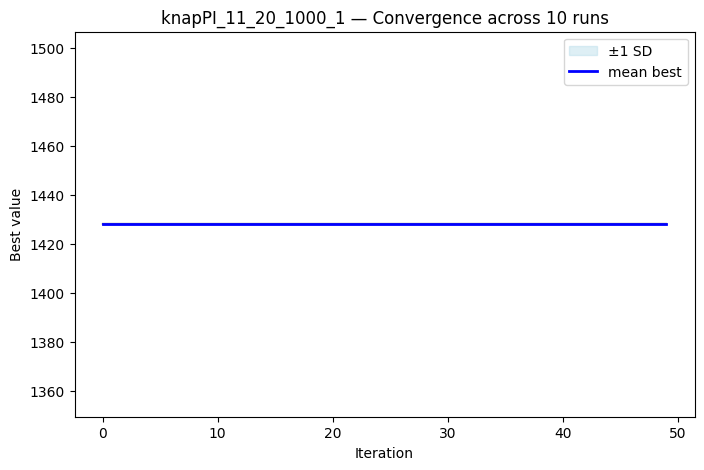

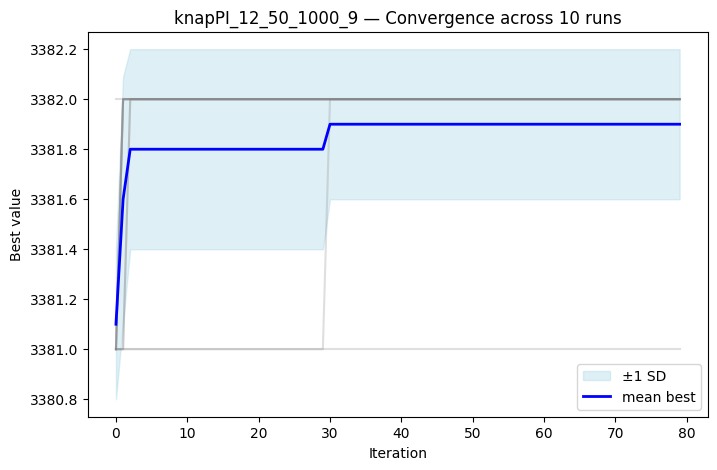

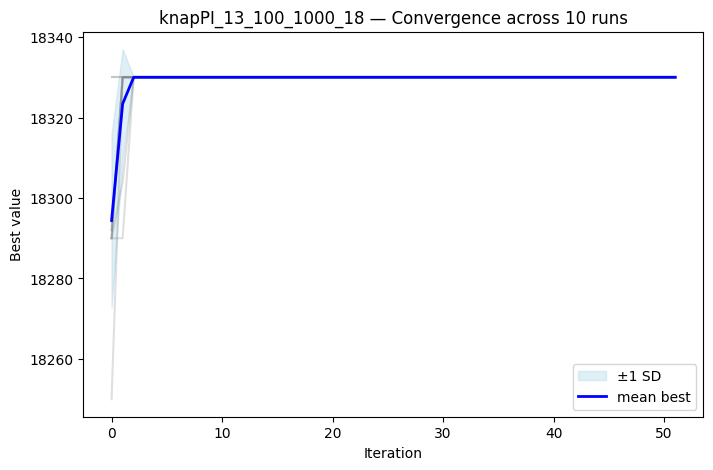

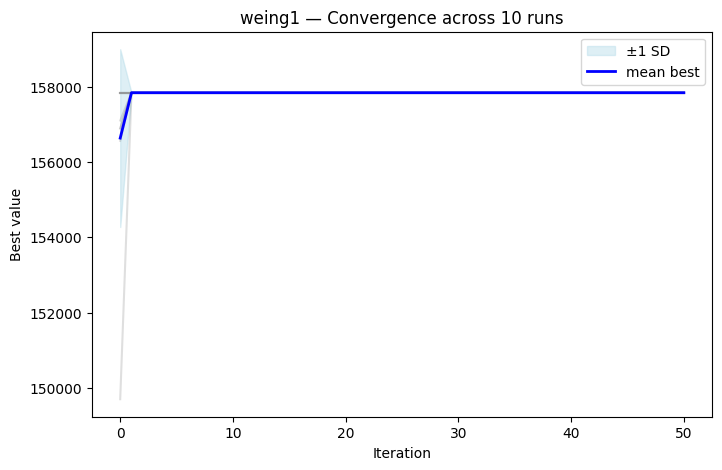

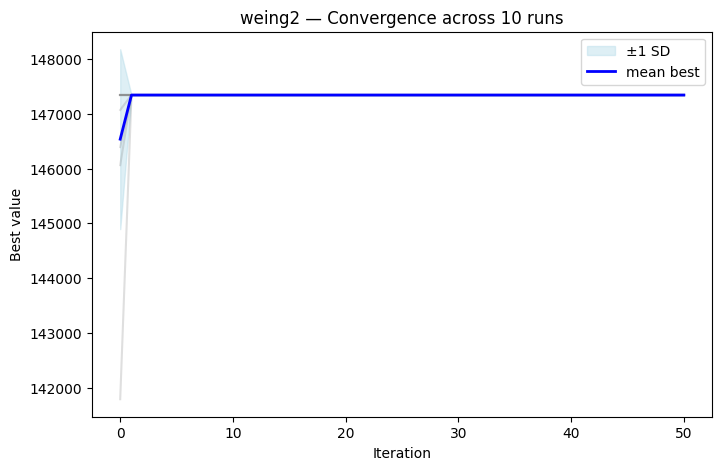

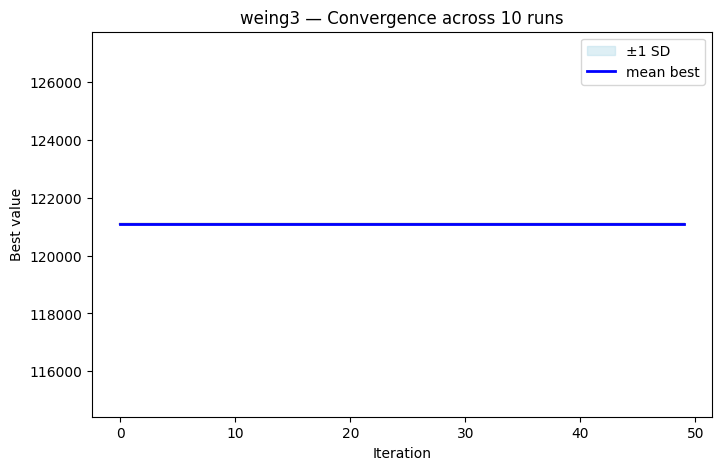

In [20]:
for inst in instances:
    stats_list = all_details[f"{inst.name}_stats"]
    plot_convergence_multi(stats_list, title=f"{inst.name} — Convergence across 10 runs")

In [21]:
def plot_fitness_vs_best(stats: BAStats, title="Population fitness vs best value"):
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(stats.avg_fitness, color="orange", label="avg fitness")
    ax2 = ax1.twinx()
    ax2.plot(stats.best_values, color="blue", label="best value")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Avg fitness", color="orange")
    ax2.set_ylabel("Best value", color="blue")
    plt.title(title)
    plt.show()

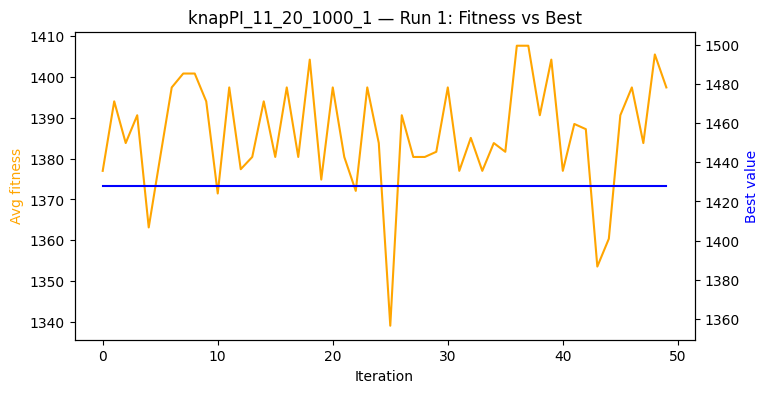

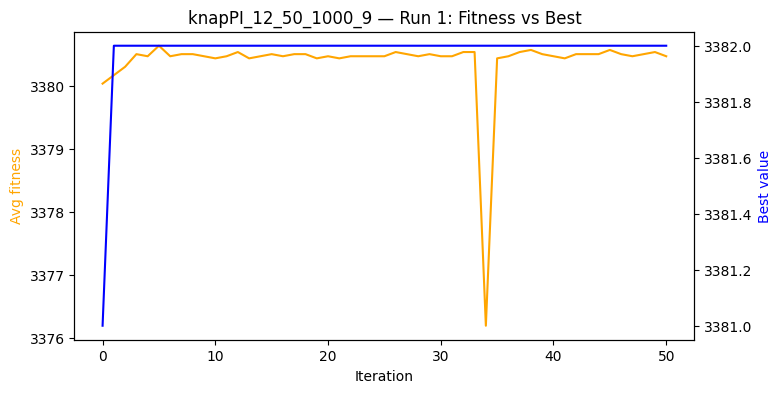

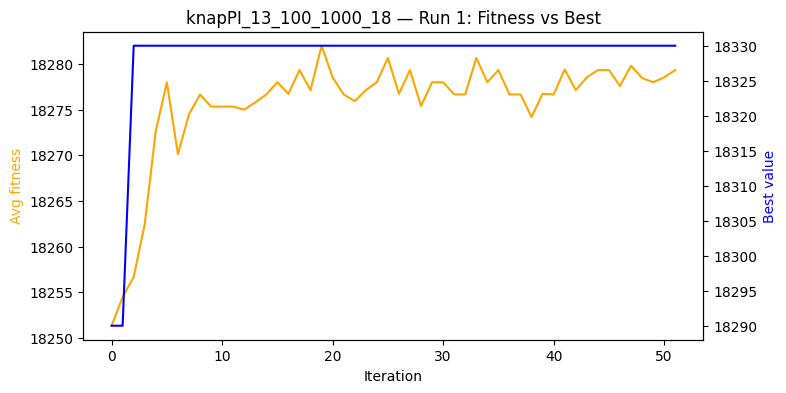

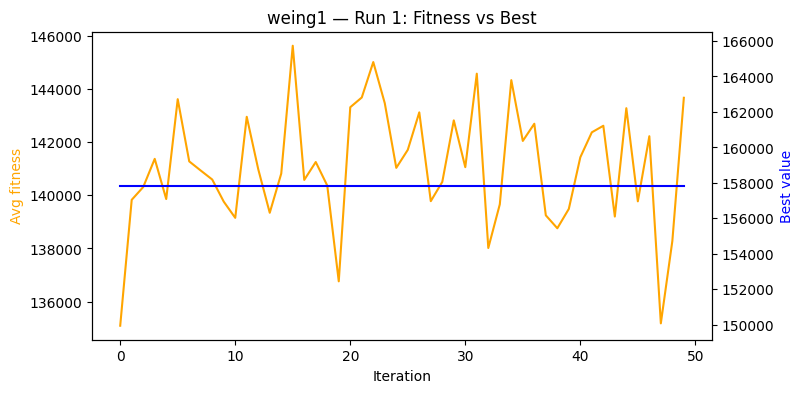

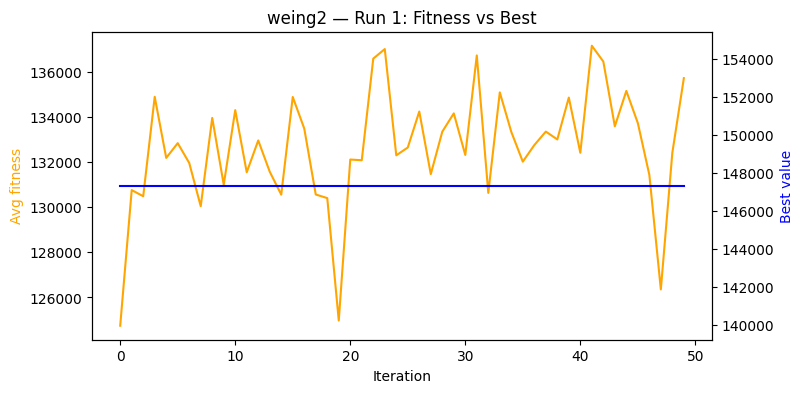

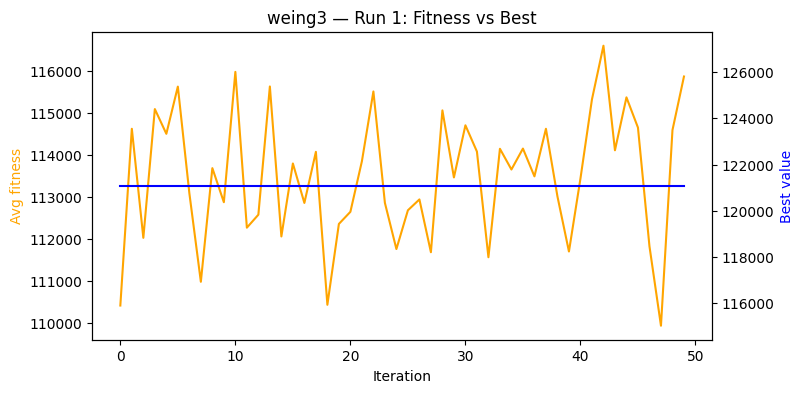

In [22]:
for inst in instances:
    stats_list = all_details[f"{inst.name}_stats"]
    plot_fitness_vs_best(stats_list[0], f"{inst.name} — Run 1: Fitness vs Best")

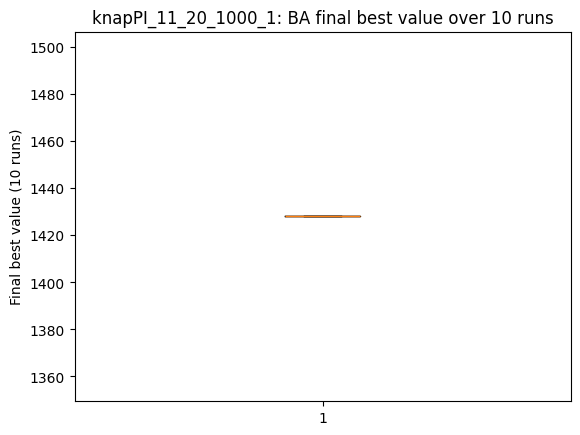

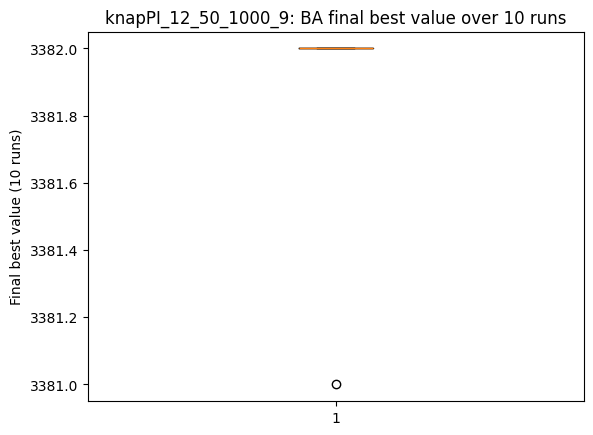

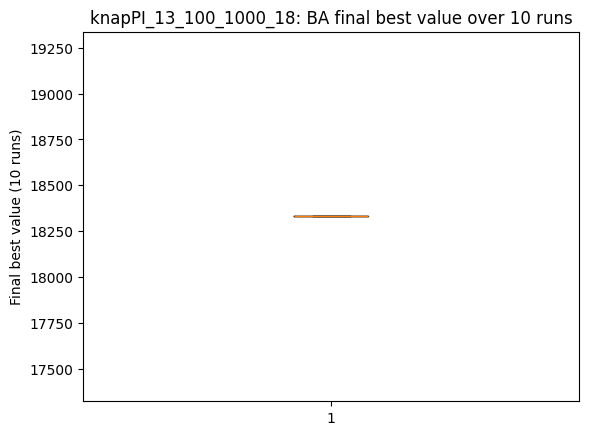

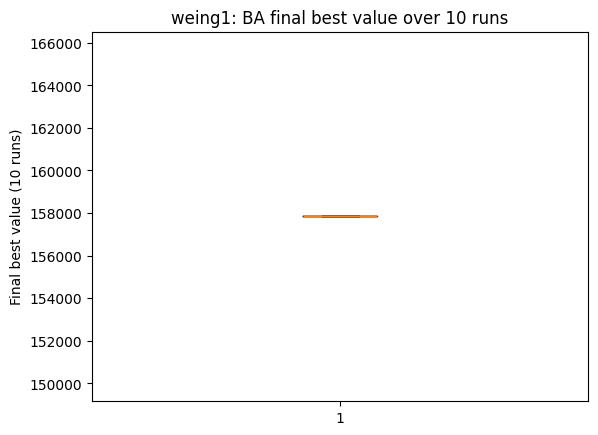

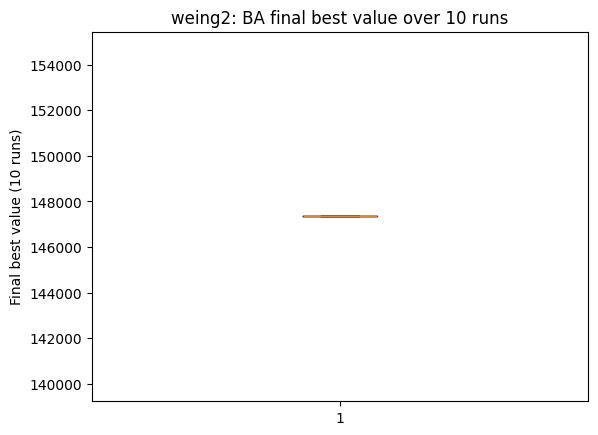

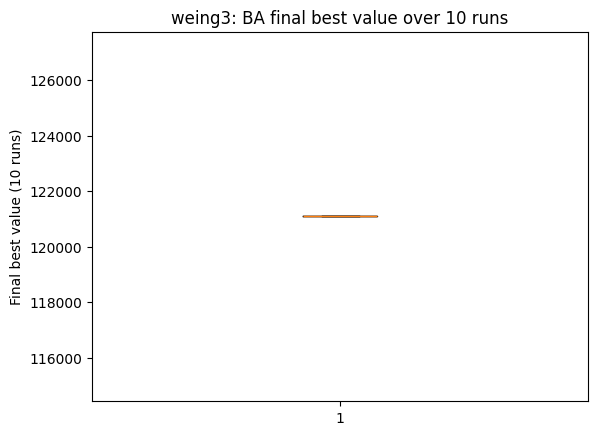

In [23]:
# Boxplots for the 10-run distribution (value)
for inst in instances:
    show_run_boxplot(all_details[inst.name], f"{inst.name}: BA final best value over 10 runs")

In [24]:
def sensitivity_grid(inst: KnapsackInstance, grid: List[Tuple[int,int,int]], seeds=range(10)):
    rows = []
    for nre, nrb, ngh in grid:
        p = dataclasses.replace(ba_params, nre=nre, nrb=nrb, ngh_init=ngh)
        vals = []
        for s in seeds:
            p2 = dataclasses.replace(p, seed=s)
            res, _ = run_ba_on_instance(inst, p2)
            vals.append(res["best_value"])
        rows.append({"nre": nre, "nrb": nrb, "ngh_init": ngh,
                     "mean": np.mean(vals), "std": np.std(vals, ddof=1),
                     "best": np.max(vals), "worst": np.min(vals)})
    return pd.DataFrame(rows)

sens_inst = instances[0]  # e.g., knapPI_11_20_1000_1
grid = [(nre, nrb, ngh) for nre in (10,20,40) for nrb in (5,10,20) for ngh in (2,3,5)]
sens_df = sensitivity_grid(sens_inst, grid)
sens_df.sort_values("mean", ascending=False)

,nre,nrb,ngh_init,mean,std,best,worst
0,10,5,2,1428.0,0.0,1428,1428
1,10,5,3,1428.0,0.0,1428,1428
2,10,5,5,1428.0,0.0,1428,1428
3,10,10,2,1428.0,0.0,1428,1428
4,10,10,3,1428.0,0.0,1428,1428
5,10,10,5,1428.0,0.0,1428,1428
6,10,20,2,1428.0,0.0,1428,1428
7,10,20,3,1428.0,0.0,1428,1428
8,10,20,5,1428.0,0.0,1428,1428
9,20,5,2,1428.0,0.0,1428,1428
